# Решение задачи кластеризации методом "K-means"

Распределение объектов по кластерам:
    legs  hair  feathers  eggs  milk  airborne  predator  toothed  backbone  \
2    4.0   1.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
3    4.0   1.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
4    4.0   1.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
5    0.0   0.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
6    2.0   0.0       1.0   1.0   0.0       1.0       1.0      0.0       1.0   
7    2.0   0.0       1.0   1.0   0.0       0.0       0.0      0.0       1.0   
8    2.0   0.0       1.0   1.0   0.0       0.0       0.0      0.0       1.0   
9    4.0   0.0       0.0   1.0   0.0       0.0       1.0      1.0       1.0   
10   4.0   0.0       0.0   1.0   0.0       0.0       0.0      0.0       1.0   
11   0.0   0.0       0.0   1.0   0.0       0.0       1.0      1.0       1.0   
12   0.0   0.0       0.0   1.0   0.0       0.0       1.0      1.0       1.0   
13   4.0   0.0 

C:\Users\ivanu\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
C:\Users\ivanu\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\ivanu\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:794: UserWarning: The provided input is a square matrix. Note that ``fit`` constructs a dissimilarity matrix from data and will treat rows as samples and columns as features. To use a pre-computed dissimilarity matrix, set ``metric='precomputed'``.
  warnings.warn(


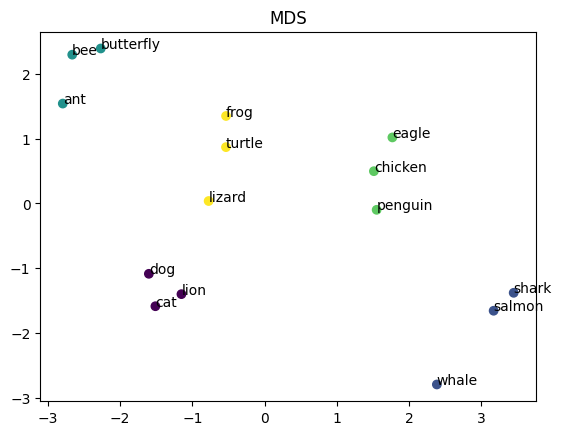

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import MDS

DATA_PATH = '../dataset/zoo.tab'
CLUSTERS = 5

# Подготовка обучающего Dataset
df = pd.read_csv(DATA_PATH, sep='\t')
animals = df['animal'][2:]
features_df = df.drop('animal', axis=1).apply(pd.to_numeric, errors='coerce').dropna()

# Кластеризация
kmeans = KMeans(n_clusters=CLUSTERS, n_init=20)
clusters = kmeans.fit_predict(features_df)
features_df['cluster'] = clusters
features_df['animal'] = animals
print(f"Распределение объектов по кластерам:\n{features_df}")

# Диаграмму MDS
mds_point = MDS().fit_transform(features_df.drop(columns=['animal', 'cluster'], axis=1))

plt.scatter(mds_point[:,0], mds_point[:,1], c=clusters, cmap='viridis')
plt.title('MDS')

for i, animal in enumerate(animals):
    plt.annotate(animal, (mds_point[i, 0], mds_point[i, 1]))
plt.show()

# Решение задачи кластеризации методом "Иерархическая кластеризация"


Распределение объектов по кластерам: 
    legs  hair  feathers  eggs  milk  airborne  predator  toothed  backbone  \
2    4.0   1.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
3    4.0   1.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
4    4.0   1.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
5    0.0   0.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
6    2.0   0.0       1.0   1.0   0.0       1.0       1.0      0.0       1.0   
7    2.0   0.0       1.0   1.0   0.0       0.0       0.0      0.0       1.0   
8    2.0   0.0       1.0   1.0   0.0       0.0       0.0      0.0       1.0   
9    4.0   0.0       0.0   1.0   0.0       0.0       1.0      1.0       1.0   
10   4.0   0.0       0.0   1.0   0.0       0.0       0.0      0.0       1.0   
11   0.0   0.0       0.0   1.0   0.0       0.0       1.0      1.0       1.0   
12   0.0   0.0       0.0   1.0   0.0       0.0       1.0      1.0       1.0   
13   4.0   0.

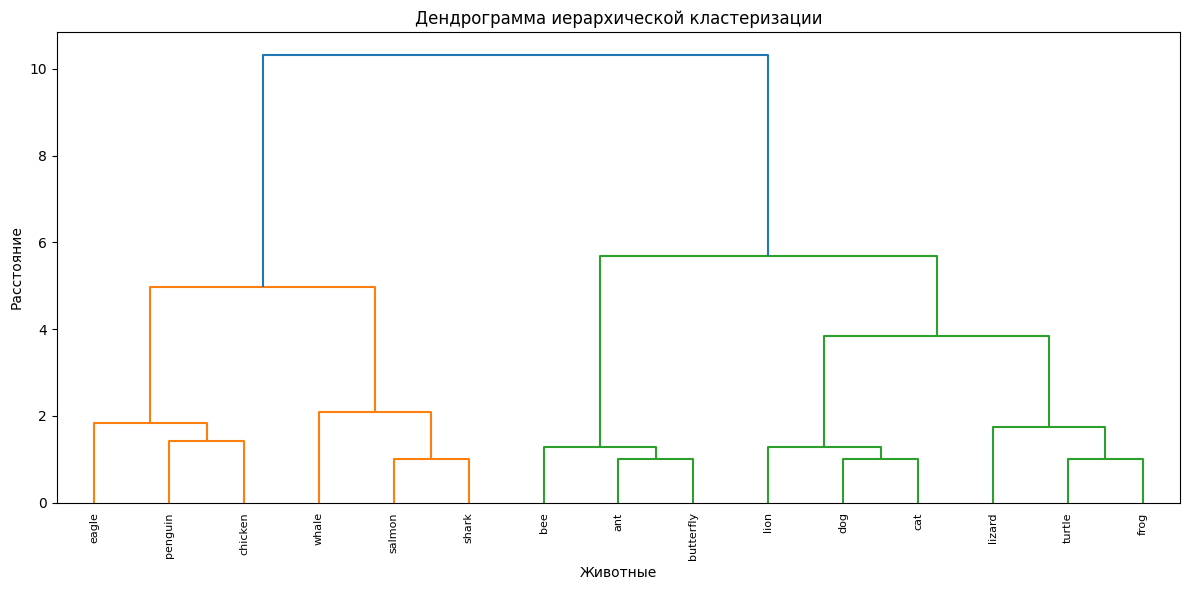

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

DATA_PATH = '../dataset/zoo.tab'
N_CLUSTERS = 5

# Подготовка обучающего dataset
df = pd.read_csv(DATA_PATH, sep='\t')
animals = df.iloc[:, 0].copy()
numeric_rows = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
numeric_rows_index = numeric_rows.dropna().index
numeric_rows = numeric_rows.loc[numeric_rows_index]
animals = animals.loc[numeric_rows_index]

# Иерархическая кластеризация
clustering = AgglomerativeClustering(n_clusters=N_CLUSTERS)
clusters = clustering.fit_predict(numeric_rows)

# Сохраняю метки кластеров в DataFrame для удобства отображения результата обучения в логах
X_clustered = numeric_rows.copy()
X_clustered['cluster'] = clusters
X_clustered['animal'] = animals

print(f'\nРаспределение объектов по кластерам: \n{X_clustered}')

# Построение дендограммы
distance_matrix = pdist(numeric_rows, metric='euclidean')
linkage_matrix = linkage(distance_matrix, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=animals.values, leaf_rotation=90, leaf_font_size=8)
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Животные')
plt.ylabel('Расстояние')
plt.tight_layout()
plt.show()


# Решение задачи классификации методом "Логистическая регрессия"


Точность модели: 0.880


C:\Users\ivanu\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


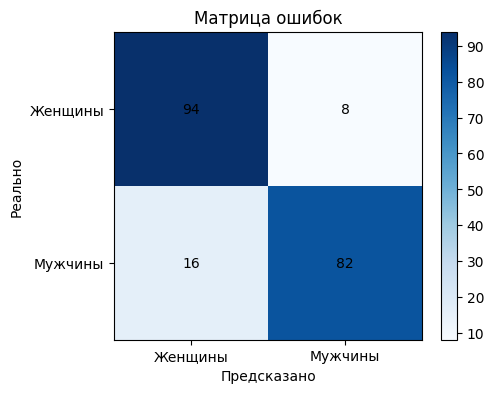

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

# Подготовка обучающего Dataset
DATA_PATH = '../dataset/students_performance.csv'
df = pd.read_csv(DATA_PATH)

# Преобразуем пол в числовое значение (1|0)
gender_df = df.get('gender').map({'male': 1, 'female': 0}).to_frame()
scores_df = df[['math score', 'reading score', 'writing score']].copy()

# Делим данные из нашего dataset на учебные и тестовые
x_train, x_test, y_train, y_test = train_test_split(scores_df, gender_df, test_size=0.2)

# Масштабируем данные
scaler = StandardScaler()
x_trained_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

# Обучение модели
model = LogisticRegression(max_iter=1000)
model.fit(x_trained_scaled, y_train)

y_pred = model.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность модели: {accuracy:.3f}")

# Строим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.xticks([0,1], ['Женщины', 'Мужчины'])
plt.yticks([0,1], ['Женщины', 'Мужчины'])
plt.xlabel('Предсказано')
plt.ylabel('Реально')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')
plt.title('Матрица ошибок')
plt.show()

# Решение задачи классификации методом "Дерево решений"

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score

# Подготовка обучающего Dataset
DATA_PATH = '../dataset/students_performance.csv'
df = pd.read_csv(DATA_PATH)

# Преобразуем пол в числовое значение (1|0)
gender_df = df.get('gender').map({'male': 1, 'female': 0}).to_frame()
scores_df = df[['math score', 'reading score', 'writing score']].copy()

# Делим данные из нашего dataset на учебные и тестовые
x_train, x_test, y_train, y_test = train_test_split(scores_df, gender_df, test_size=0.2, random_state=42)

# Обучение модели
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность модели: {accuracy:.3f}")

# Строим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.xticks([0,1], ['Женщины', 'Мужчины'])
plt.yticks([0,1], ['Женщины', 'Мужчины'])
plt.xlabel('Предсказано')
plt.ylabel('Реально')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')
plt.title('Матрица ошибок (Дерево решений)')
plt.show()

# Визуализация дерева решений
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=scores_df.columns.tolist(),
    class_names=['Женщины', 'Мужчины'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Структура дерева решений', fontsize=16)
plt.show()